# 06 · Evaluación consolidada

- **Proyecto:** Detección de Residuos Urbanos · Computer Vision · UNI 2026-I
- **Autor:** Jairzinho Santos

Une los resultados de P0 (notebook 04) y P1 (notebook 05) en los artefactos finales:
tabla maestra, comparativa entre familias, matriz cross-domain, los tres análisis de P1
y la descomposición de errores TIDE.

**Se puede ejecutar en cualquier momento**: cada sección se salta con aviso si sus
insumos aún no existen y se completa sola al reejecutar cuando los carriles (Mac y
Colab) vayan cerrando experimentos. Ningún entrenamiento ocurre aquí solo lectura
de `experiments/` y de los GT de gold.

| Insumo | Origen |
|---|---|
| `experiments/p0/<exp>/DONE.json` + `predicciones_test.json` | notebook 04 |
| `experiments/p1/<exp>/DONE.json` + `preds_*.json` + análisis | notebook 05 |
| `gold/coco/*_test.json` | notebook 03 (fuente única de verdad métrica) |

Salidas: `reports/tablas/` (CSV para el paper) · `reports/figuras_final/` ·
`reports/resultados_finales.json`.

## Parte 0 · Configuración

In [1]:
import sys, subprocess, importlib

def _asegurar(paquetes):
    faltan = []
    for p, m in paquetes:
        try:
            importlib.import_module(m)
        except ImportError:
            faltan.append(p)
    if faltan:
        print("instalando:", faltan)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + faltan, check=False)

_asegurar([("pycocotools", "pycocotools"), ("pandas", "pandas"),
           ("matplotlib", "matplotlib"), ("tidecv", "tidecv")])

import os, json, time, math, shutil, datetime, collections, contextlib, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
from IPython.display import display

_cwd     = Path.cwd()
CODE_DIR = _cwd.parent if _cwd.name == "notebooks" else _cwd
GOLD     = CODE_DIR / "data" / "gold"
RUNS_P0  = CODE_DIR / "experiments" / "p0"
RUNS_P1  = CODE_DIR / "experiments" / "p1"
FIG_DIR  = CODE_DIR / "reports" / "figuras_final"
TAB_DIR  = CODE_DIR / "reports" / "tablas"
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUPERFICIE = "#fcfcfb"; TINTA_1 = "#1a1a19"; TINTA_2 = "#52514e"; TINTA_3 = "#8a8a80"
REJILLA = "#e6e5e0"
PAL = {"taco": "#2a78d6", "rolid": "#eb6834", "uav": "#1baf7a"}
COL_FAM = {"FRCNN": "#2a78d6", "YOLO": "#eb6834", "FCN": "#1baf7a", "VGG": "#8a8a80"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 170,
    "figure.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE, "axes.edgecolor": REJILLA,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": REJILLA,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": TINTA_1,
    "axes.labelsize": 9, "axes.labelcolor": TINTA_2,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.fontsize": 8, "legend.frameon": False,
    "font.family": "sans-serif", "font.size": 9,
})


def titulo(txt, ancho=96):
    print("\n" + "═" * ancho); print(txt); print("═" * ancho)


def tabla(df, maxfilas=60):
    with pd.option_context("display.max_rows", maxfilas, "display.width", 220,
                           "display.max_columns", 50, "display.float_format", "{:,.4f}".format):
        display(df)


def mostrar(fig, nombre=None):
    try:
        fig.tight_layout()
    except Exception:
        pass
    if nombre:
        fig.savefig(FIG_DIR / "{}.png".format(nombre), bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    display(fig)
    plt.close(fig)


def done(runs, exp):
    p = runs / exp / "DONE.json"
    return json.loads(p.read_text()) if p.exists() else None


print("RUNS_P0:", RUNS_P0, "| RUNS_P1:", RUNS_P1)

RUNS_P0: /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/experiments/p0 | RUNS_P1: /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/experiments/p1


## Parte 1 · Inventario de resultados disponibles

In [2]:
PLAN_P0 = ["E1", "E2", "E3", "E4", "D1", "D2", "A1", "A2", "B6", "B5", "C"]
PLAN_P1 = ["F1", "F2", "F3", "F4", "G1", "G2", "H1", "H2"]

titulo("INVENTARIO")
filas = []
for runs, plan, fase in ((RUNS_P0, PLAN_P0, "P0"), (RUNS_P1, PLAN_P1, "P1")):
    for e in plan:
        d = runs / e
        if (d / "DONE.json").exists():
            est = "DONE"
        elif (d / "FAILED.json").exists():
            est = "FAILED"
        elif d.exists():
            est = "PARCIAL"
        else:
            est = "PENDING"
        preds = sorted(d.glob("pred*_*.json")) + sorted(d.glob("predicciones_*.json"))
        filas.append({"fase": fase, "exp": e, "estado": est, "preds": len(preds)})
inv = pd.DataFrame(filas).set_index(["fase", "exp"])
tabla(inv, maxfilas=25)
n_done = int((inv["estado"] == "DONE").sum())
print("\ndisponibles: {}/19 experimentos DONE".format(n_done))
if n_done == 0:
    print("[aviso] sin resultados aún: todas las secciones siguientes se saltarán con aviso")


════════════════════════════════════════════════════════════════════════════════════════════════
INVENTARIO
════════════════════════════════════════════════════════════════════════════════════════════════


estado  preds
fase exp              
P0   E1    DONE      0
     E2    DONE      0
     E3    DONE      0
     E4    DONE      0
     D1    DONE      0
     D2    DONE      0
     A1    DONE      2
     A2    DONE      2
     B6    DONE      2
     B5    DONE      2
     C     DONE      2
P1   F1    DONE      3
     F2    DONE      3
     F3    DONE      2
     F4    DONE      3
     G1    DONE      1
     G2    DONE      1
     H1    DONE      1
     H2    DONE      1


disponibles: 19/19 experimentos DONE


## Parte 2 · Tabla maestra de resultados


════════════════════════════════════════════════════════════════════════════════════════════════
TABLA MAESTRA
════════════════════════════════════════════════════════════════════════════════════════════════


familia          tarea               datos        detalle  epocas  tiempo_min    val metrica_val  test_acc  test_iou_litter  test_ap50  test_ap  test_ap_s
fase exp                                                                                                                                                           
P0   E1      VGG  clasificación         crops/masks      congelado      15     30.7000 0.9699     val_acc    0.9712              NaN        NaN      NaN        NaN
     E2      VGG  clasificación         crops/masks      congelado      30     61.2000 0.9716     val_acc    0.9713              NaN        NaN      NaN        NaN
     E3      VGG  clasificación         crops/masks  ultimo_bloque      15     35.4000 0.9687     val_acc    0.9737              NaN        NaN      NaN        NaN
     E4      VGG  clasificación         crops/masks  ultimo_bloque      22     52.0000 0.9771     val_acc    0.9782              NaN        NaN      NaN        NaN
     D1      FCN   segmentación         crops/masks         0.0010      68      7.3000 0.5498     val_iou       NaN           0.5766        NaN      NaN        NaN
     D2      FCN   segmentación         crops/masks         0.0001      70      7.5000 0.4690     val_iou       NaN           0.5357        NaN      NaN        NaN
     A1    FRCNN      detección           taco_1cls      congelado      26     19.7000 0.5329    val_ap50       NaN              NaN     0.4460   0.3006     0.0585
     A2    FRCNN      detección           taco_1cls         layer4      18     14.0000 0.5420    val_ap50       NaN              NaN     0.4826   0.3231     0.0729
     B6    FRCNN      detección           taco_6cls         layer4      25     18.9000 0.2490    val_ap50       NaN              NaN     0.2457   0.1536     0.0286
     B5    FRCNN      detección           taco_5cls         layer4      23     17.2000 0.2828    val_ap50       NaN              NaN     0.2441   0.1555     0.0245
     C     FRCNN      detección    rolid_video_1cls         layer4      14     67.1000 0.7079    val_ap50       NaN              NaN     0.7075   0.2767     0.2812
P1   F1     YOLO      detección           taco_1cls           @640     150    138.4000 0.5405    val_ap50       NaN              NaN     0.4418   0.3178     0.0563
     F2     YOLO      detección    rolid_video_1cls           @640      93    104.0000 0.7311    val_ap50       NaN              NaN     0.6954   0.2788     0.2789
     F3     YOLO      detección  rolid_oficial_1cls           @640      94    107.9000 0.6522    val_ap50       NaN              NaN     0.6201   0.2297        NaN
     F4     YOLO      detección            uav_1cls           @640     150      9.9000 0.7390    val_ap50       NaN              NaN     0.7792   0.4570     0.3744
     G1     YOLO      detección           taco_6cls           @640      93     13.6000 0.2141    val_ap50       NaN              NaN     0.1566      NaN        NaN
     G2     YOLO      detección           taco_5cls           @640     148     21.1000 0.2631    val_ap50       NaN              NaN     0.1922      NaN        NaN
     H1     YOLO      detección           taco_1cls          @1024     133     44.9000 0.5684    val_ap50       NaN              NaN     0.4735      NaN     0.0957
     H2     YOLO      detección    rolid_video_1cls          @1024      76    170.2000 0.7969    val_ap50       NaN              NaN     0.7787      NaN     0.3371


exportada -> /Volumes/JS-MAIN/Personal/Education/UNI/AI Master/Semesters & Class/Semester 3/Computer Vision/final-project/code/reports/tablas/resultados_maestros.csv


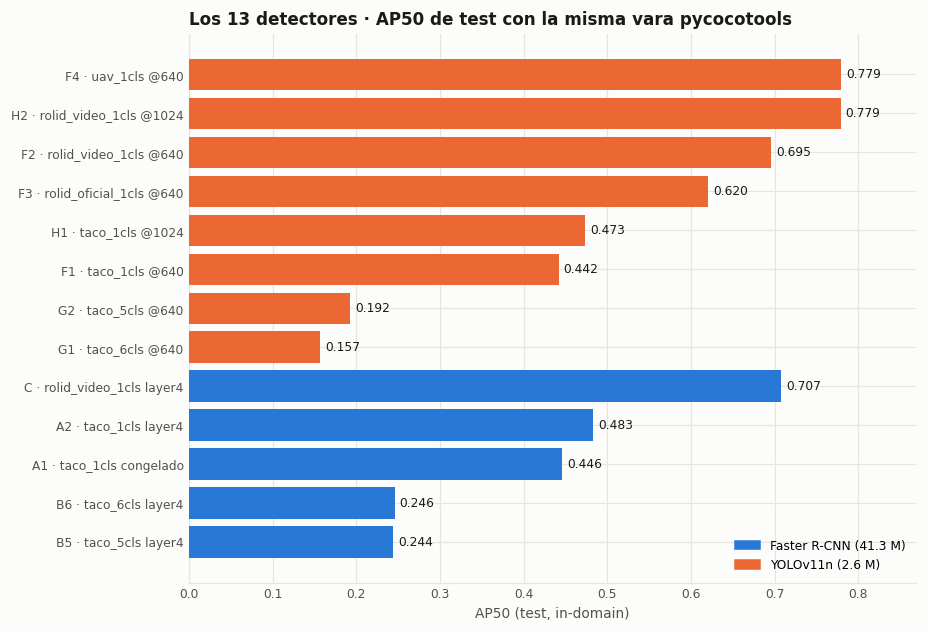

In [3]:
titulo("TABLA MAESTRA")

FAMILIA = {"E": ("VGG", "clasificación"), "D": ("FCN", "segmentación"),
           "A": ("FRCNN", "detección"), "B": ("FRCNN", "detección"),
           "C": ("FRCNN", "detección"), "F": ("YOLO", "detección"),
           "G": ("YOLO", "detección"), "H": ("YOLO", "detección")}


def _test_p1():
    """Los DONE de P1 no llevan bloque 'test': sus métricas de test viven en los
    análisis de la notebook 05 (los mismos preds evaluados con pycocotools). Se
    recuperan aquí para que la maestra mida a las dos familias con la misma vara."""
    t = {}
    p = RUNS_P1 / "matriz_cross_domain.json"
    if p.exists():
        det = json.loads(p.read_text())
        for dom, exp in (("taco", "F1"), ("rolid", "F2"), ("uav", "F4")):
            v = det.get(dom + "->" + dom)
            if v:
                t[exp] = {"ap50": v["ap50"], "ap": v["ap"], "ap_s": v["ap_s"]}
    p = RUNS_P1 / "oficial_vs_video.json"
    if p.exists():
        v = json.loads(p.read_text()).get("oficial (58% fuga)")
        if v:
            t["F3"] = {"ap50": v["AP50"], "ap": v["AP"]}
    p = RUNS_P1 / "ablacion_resolucion.json"
    if p.exists():
        d = json.loads(p.read_text())
        for ds, exp in (("taco", "H1"), ("rolid", "H2")):
            v = d.get(ds)
            if v:
                t[exp] = {"ap50": v["AP50@1024"], "ap_s": v["AP_s@1024"]}
    p = RUNS_P1 / "variantes_ab.json"
    if p.exists():
        g = json.loads(p.read_text()).get("_global", {})
        if g.get("A_6cls") is not None:
            t["G1"] = {"ap50": g["A_6cls"]}
        if g.get("B_5cls") is not None:
            t["G2"] = {"ap50": g["B_5cls"]}
    return t


TEST_P1 = _test_p1()

filas = []
for runs, plan, fase in ((RUNS_P0, PLAN_P0, "P0"), (RUNS_P1, PLAN_P1, "P1")):
    for e in plan:
        m = done(runs, e)
        if not m:
            continue
        fam, tarea = FAMILIA[e[0]]
        cfg = m.get("config", {})
        fila = {"fase": fase, "exp": e, "familia": fam, "tarea": tarea,
                "datos": cfg.get("exp_gold") or cfg.get("gold") or "crops/masks",
                "detalle": cfg.get("estrategia") or ("@{}".format(cfg.get("imgsz")) if cfg.get("imgsz") else cfg.get("lr", "")),
                "epocas": m.get("epocas_efectivas"),
                "tiempo_min": round(m.get("tiempo_total_s", m.get("tiempo_s", 0)) / 60, 1)}
        mejor = m.get("mejor", {})
        test = m.get("test", {}) or (TEST_P1.get(e, {}) if fase == "P1" else {})
        fila["val"] = next(iter(mejor.values()), None)
        fila["metrica_val"] = next(iter(mejor.keys()), "")
        for k in ("ap50", "ap", "ap_s", "acc", "iou_litter"):
            if k in test:
                fila["test_" + k] = test[k]
        filas.append(fila)

if filas:
    maestra = pd.DataFrame(filas).set_index(["fase", "exp"])
    tabla(maestra, maxfilas=25)
    maestra.to_csv(TAB_DIR / "resultados_maestros.csv")
    print("\nexportada -> {}".format(TAB_DIR / "resultados_maestros.csv"))

    det = maestra.reset_index()
    if "test_ap50" in det.columns:
        det = det[det["test_ap50"].notna()].copy()
    else:
        det = det.iloc[0:0]
    if len(det):
        det["etiqueta"] = det.apply(
            lambda r: "{} · {} {}".format(r["exp"], r["datos"], r["detalle"]), axis=1)
        det = det.sort_values(["familia", "test_ap50"])
        fig, ax = plt.subplots(figsize=(8.5, 0.34 * len(det) + 1.4))
        ax.barh(det["etiqueta"], det["test_ap50"],
                color=[COL_FAM[f] for f in det["familia"]], zorder=3)
        for y, v in enumerate(det["test_ap50"]):
            ax.text(v + 0.006, y, "{:.3f}".format(v), va="center", fontsize=8,
                    color=TINTA_1)
        ax.set_xlabel("AP50 (test, in-domain)")
        ax.set_xlim(0, min(1.0, det["test_ap50"].max() + 0.09))
        ax.set_title("Los 13 detectores · AP50 de test con la misma vara pycocotools",
                     loc="left")
        _leyenda = [plt.Rectangle((0, 0), 1, 1, color=COL_FAM[f])
                    for f in ("FRCNN", "YOLO")]
        ax.legend(_leyenda, ["Faster R-CNN (41.3 M)", "YOLOv11n (2.6 M)"],
                  loc="lower right")
        mostrar(fig, "resultados_maestros")
else:
    maestra = None
    print("[omitido] sin experimentos DONE")

## Parte 3 · Comparativa entre familias

Los pares directos FRCNN vs YOLO sobre los mismos datos y splits, con eficiencia:
la fila que sostiene el argumento "modelo ligero desplegable" del paper.

exp  test_AP50  test_AP  test_AP_s  params_M  tiempo_h
datos            familia                                                       
taco_1cls        FRCNN    A1     0.4460   0.3006     0.0585   41.3000    0.3300
                 YOLO     F1     0.4418   0.3178     0.0563    2.6000    2.3100
taco_6cls        FRCNN    B6     0.2457   0.1536     0.0286   41.3000    0.3200
                 YOLO     G1     0.1566      NaN        NaN    2.6000    0.2300
taco_5cls        FRCNN    B5     0.2441   0.1555     0.0245   41.3000    0.2900
                 YOLO     G2     0.1922      NaN        NaN    2.6000    0.3500
rolid_video_1cls FRCNN     C     0.7075   0.2767     0.2812   41.3000    1.1200
                 YOLO     F2     0.6954   0.2788     0.2789    2.6000    1.7300

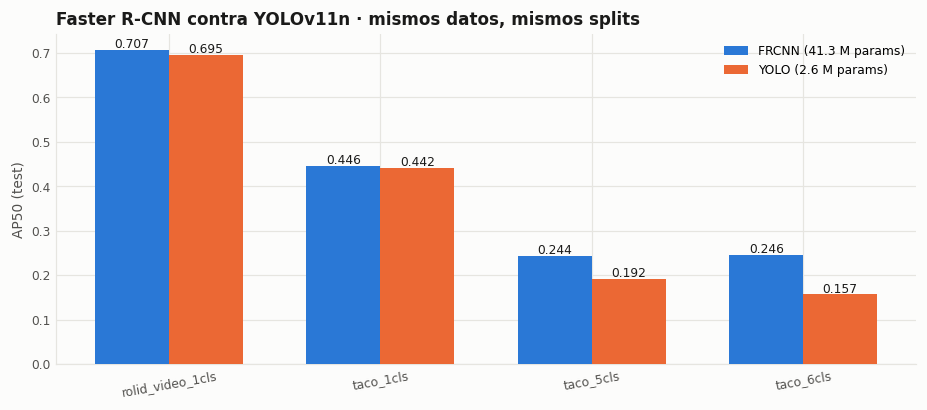

In [4]:
PARAMS_M = {"FRCNN": 41.3, "YOLO": 2.6}     # millones, R50-FPN vs YOLOv11n

PARES = [("taco_1cls", "A1", RUNS_P0, "F1", RUNS_P1),
         ("taco_6cls", "B6", RUNS_P0, "G1", RUNS_P1),
         ("taco_5cls", "B5", RUNS_P0, "G2", RUNS_P1),
         ("rolid_video_1cls", "C", RUNS_P0, "F2", RUNS_P1)]

filas = []
for datos, e0, r0, e1, r1 in PARES:
    for exp, runs, fam in ((e0, r0, "FRCNN"), (e1, r1, "YOLO")):
        m = done(runs, exp)
        if not m:
            continue
        test = m.get("test", {})
        if "ap50" not in test:
            # los DONE de P1 no llevan bloque 'test': se toma del mismo TEST_P1
            # que alimenta la maestra (análisis de la 05, misma vara pycocotools)
            test = globals().get("TEST_P1", {}).get(exp, {})
        if "ap50" not in test:
            continue
        filas.append({"datos": datos, "familia": fam, "exp": exp,
                      "test_AP50": test["ap50"], "test_AP": test.get("ap"),
                      "test_AP_s": test.get("ap_s"),
                      "params_M": PARAMS_M[fam],
                      "tiempo_h": round(m.get("tiempo_total_s", m.get("tiempo_s", 0)) / 3600, 2)})

if filas:
    comp = pd.DataFrame(filas)
    tabla(comp.set_index(["datos", "familia"]))
    comp.to_csv(TAB_DIR / "comparativa_familias.csv", index=False)

    piv = comp.pivot_table(index="datos", columns="familia", values="test_AP50")
    datasets_disp = piv.index.tolist()
    x = np.arange(len(datasets_disp)); w = 0.35
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for i, fam in enumerate([f for f in ("FRCNN", "YOLO") if f in piv.columns]):
        ax.bar(x + (i - 0.5) * w, piv[fam], w, color=COL_FAM[fam],
               label="{} ({} M params)".format(fam, PARAMS_M[fam]), zorder=3)
        for xi, v in zip(x + (i - 0.5) * w, piv[fam]):
            if pd.notna(v):
                ax.text(xi, v + 0.005, "{:.3f}".format(v), ha="center", fontsize=8,
                        color=TINTA_1)
    ax.set_xticks(x); ax.set_xticklabels(datasets_disp, rotation=10)
    ax.set_ylabel("AP50 (test)")
    ax.set_title("Faster R-CNN contra YOLOv11n · mismos datos, mismos splits", loc="left")
    ax.legend()
    mostrar(fig, "comparativa_familias")
else:
    print("[omitido] aún no hay pares FRCNN/YOLO con test completado")

## Parte 4 · Matriz cross-domain

,taco,rolid,uav
taco,0.4418,0.0020,0.5266
rolid,0.0010,0.6954,0.0635
uav,0.1060,0.0060,0.7792


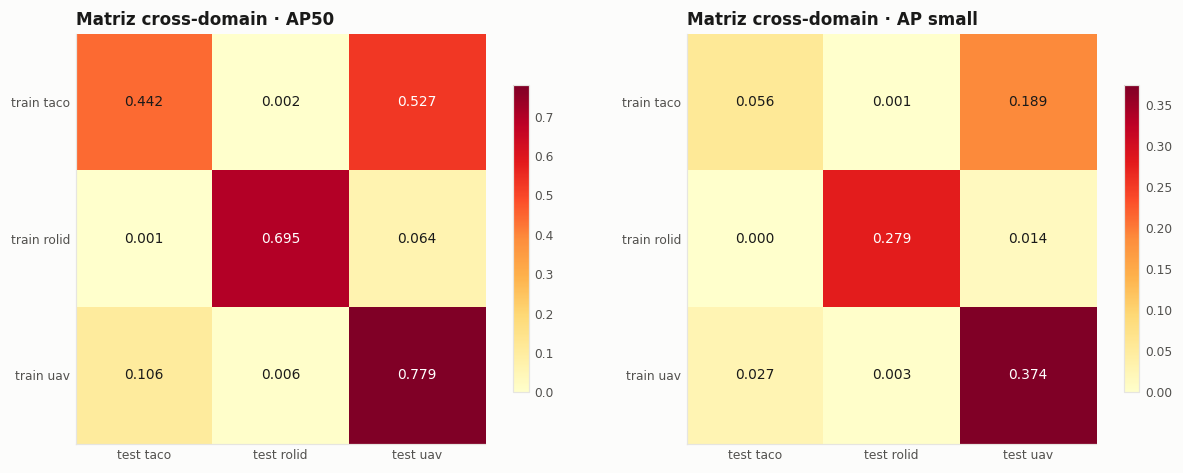

degradación media cross-domain: 82%  (in-domain 0.639 -> cruzado 0.118)


In [5]:
p_matriz = RUNS_P1 / "matriz_cross_domain.json"
if not p_matriz.exists():
    print("[omitido] requiere la celda de matriz de la notebook 05 (F1, F2 y F4 DONE)")
else:
    det = json.loads(p_matriz.read_text())
    doms = ["taco", "rolid", "uav"]
    M = pd.DataFrame(index=doms, columns=doms, dtype=float)
    Ms = pd.DataFrame(index=doms, columns=doms, dtype=float)
    for k, v in det.items():
        a, b = k.split("->")
        M.loc[a, b] = v["ap50"]; Ms.loc[a, b] = v.get("ap_s", float("nan"))
    tabla(M.round(4))
    M.to_csv(TAB_DIR / "matriz_cross_domain_ap50.csv")

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
    for ax, Mx, t in ((axes[0], M, "AP50"), (axes[1], Ms, "AP small")):
        vals = Mx.values.astype(float)
        im = ax.imshow(np.nan_to_num(vals, nan=0), cmap="YlOrRd", vmin=0)
        ax.set_xticks(range(3)); ax.set_xticklabels(["test " + c for c in doms])
        ax.set_yticks(range(3)); ax.set_yticklabels(["train " + c for c in doms])
        for i in range(3):
            for j in range(3):
                v = vals[i, j]
                ax.text(j, i, "-" if np.isnan(v) else "{:.3f}".format(v),
                        ha="center", va="center", fontsize=9,
                        color="white" if (not np.isnan(v) and v > np.nanmax(vals) * 0.6)
                        else TINTA_1)
        ax.set_title("Matriz cross-domain · " + t, loc="left"); ax.grid(False)
        fig.colorbar(im, ax=ax, shrink=0.75)
    mostrar(fig, "matriz_cross_domain_final")

    diag = np.diag(M.values.astype(float))
    fuera = M.values.astype(float)[~np.eye(3, dtype=bool)]
    if not np.isnan(diag).all():
        print("degradación media cross-domain: {:.0f}%  (in-domain {:.3f} -> cruzado {:.3f})".format(
            (1 - np.nanmean(fuera) / max(np.nanmean(diag), 1e-9)) * 100,
            np.nanmean(diag), np.nanmean(fuera)))

## Parte 5 · Los tres análisis de P1: fuga, resolución y variantes A/B


════════════════════════════════════════════════════════════════════════════════════════════════
FUGA: split oficial contra split por video (H4)
════════════════════════════════════════════════════════════════════════════════════════════════


,modelo,test,AP50,AP
oficial (58% fuga),F3,oficial,0.6201,0.2297
por video (0% fuga),F2,video,0.6954,0.2788
F3 evaluado sin fuga,F3,video,0.8439,0.3716



════════════════════════════════════════════════════════════════════════════════════════════════
ABLACIÓN DE RESOLUCIÓN 640 vs 1024
════════════════════════════════════════════════════════════════════════════════════════════════


,AP50@640,AP50@1024,AP_s@640,AP_s@1024,ganancia_AP_s
taco,0.4418,0.4735,0.0563,0.0957,0.0394
rolid,0.6954,0.7787,0.2789,0.3371,0.0582



════════════════════════════════════════════════════════════════════════════════════════════════
VARIANTES A/B: 6 clases (vidrio) contra 5
════════════════════════════════════════════════════════════════════════════════════════════════


,A_6cls,B_5cls
cigarrillo,0.0762,0.0814
metal,0.1740,0.2509
papel_carton,0.1749,0.1987
plastico_flexible,0.2214,0.2221
plastico_rigido,0.2444,0.2078
vidrio,0.0486,NaN
_global,0.1566,0.1922


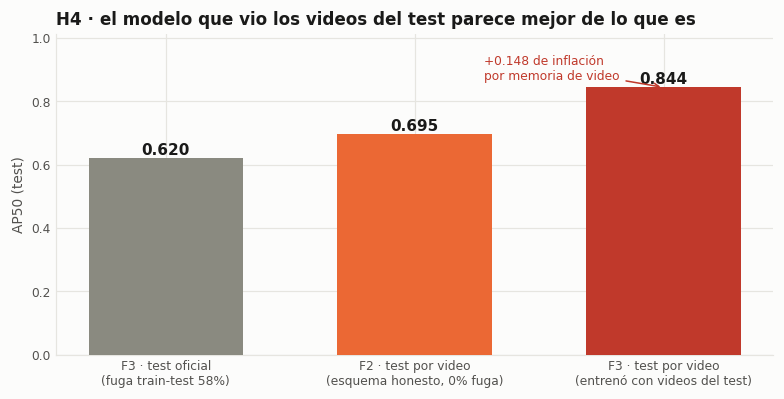

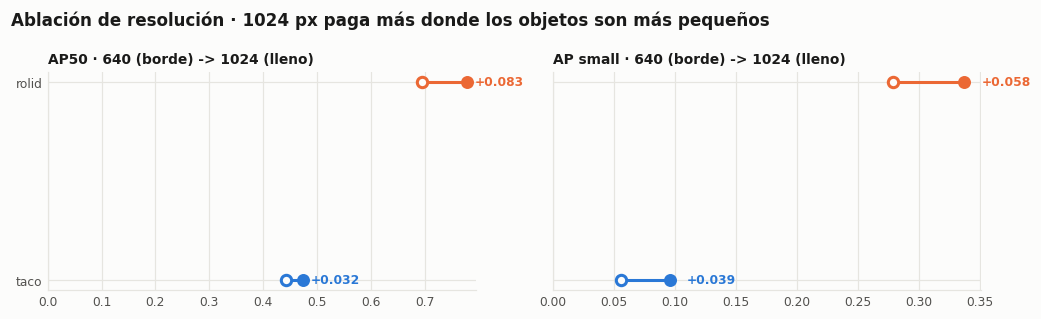

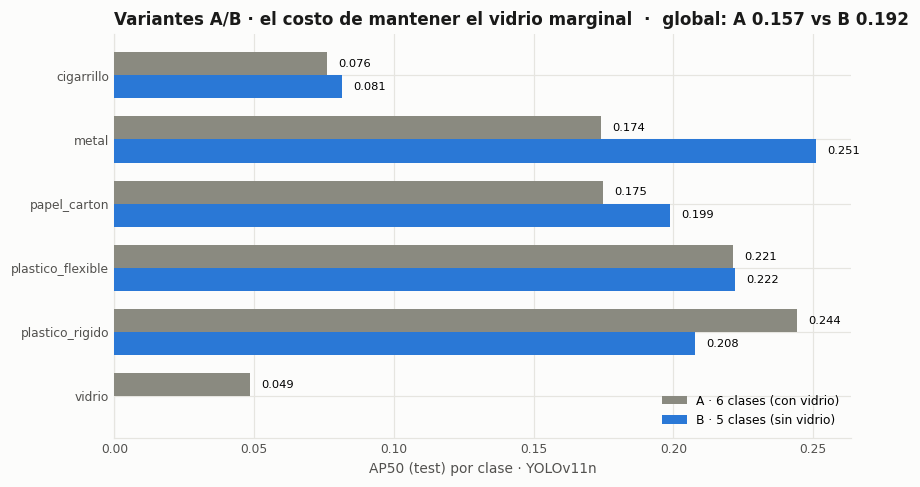

In [6]:
dfs = {}
for nombre, titulo_txt in (("oficial_vs_video", "FUGA: split oficial contra split por video (H4)"),
                           ("ablacion_resolucion", "ABLACIÓN DE RESOLUCIÓN 640 vs 1024"),
                           ("variantes_ab", "VARIANTES A/B: 6 clases (vidrio) contra 5")):
    p = RUNS_P1 / (nombre + ".json")
    titulo(titulo_txt)
    if not p.exists():
        print("[omitido] aún sin generar en la notebook 05")
        continue
    d = json.loads(p.read_text())
    df = pd.DataFrame(d).T if isinstance(d, dict) else pd.DataFrame(d)
    dfs[nombre] = df
    tabla(df)
    df.to_csv(TAB_DIR / (nombre + ".csv"))

# ── Figura · fuga: las tres evaluaciones cuentan la historia completa ─────────
df = dfs.get("oficial_vs_video")
if df is not None and "AP50" in df.columns:
    vals = df["AP50"].astype(float)
    etiq = ["F3 · test oficial\n(fuga train-test 58%)",
            "F2 · test por video\n(esquema honesto, 0% fuga)",
            "F3 · test por video\n(entrenó con videos del test)"]
    colores = [TINTA_3, PAL["rolid"], "#c0392b"]
    fig, ax = plt.subplots(figsize=(7.2, 3.7))
    ax.bar(range(len(vals)), vals, color=colores[:len(vals)], width=0.62, zorder=3)
    for x, v in enumerate(vals):
        ax.text(x, v + 0.012, "{:.3f}".format(v), ha="center", fontsize=10,
                fontweight="bold", color=TINTA_1)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(etiq[:len(vals)], fontsize=8)
    ax.set_ylabel("AP50 (test)")
    ax.set_ylim(0, float(vals.max()) * 1.2)
    if len(vals) >= 3:
        ax.annotate("+{:.3f} de inflación\npor memoria de video".format(
                        float(vals.iloc[2]) - float(vals.iloc[1])),
                    xy=(2, float(vals.iloc[2])),
                    xytext=(1.28, float(vals.iloc[2]) * 1.03),
                    fontsize=8, color="#c0392b",
                    arrowprops=dict(arrowstyle="->", color="#c0392b"))
    ax.set_title("H4 · el modelo que vio los videos del test parece mejor de lo que es",
                 loc="left")
    mostrar(fig, "fuga_oficial_vs_video")

# ── Figura · ablación: dumbbell 640 -> 1024 ──────────────────────────────────
df = dfs.get("ablacion_resolucion")
if df is not None and len(df):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.9), sharey=True)
    for ax, (c640, c1024, t) in zip(axes, (("AP50@640", "AP50@1024", "AP50"),
                                           ("AP_s@640", "AP_s@1024", "AP small"))):
        for y, (ds, fila) in enumerate(df.iterrows()):
            col = PAL.get(ds, TINTA_2)
            a, b = float(fila[c640]), float(fila[c1024])
            ax.plot([a, b], [y, y], color=col, lw=2, zorder=3)
            ax.scatter([a], [y], s=46, color=SUPERFICIE, edgecolor=col, lw=2, zorder=4)
            ax.scatter([b], [y], s=56, color=col, zorder=4)
            ax.text(b + 0.014, y, "{:+.3f}".format(b - a), va="center", fontsize=8,
                    color=col, fontweight="bold")
        ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index)
        ax.set_title("{} · 640 (borde) -> 1024 (lleno)".format(t), loc="left", fontsize=9)
        ax.set_xlim(left=0)
        ax.margins(x=0.14)
    fig.suptitle("Ablación de resolución · 1024 px paga más donde los objetos son más pequeños",
                 x=0.01, ha="left", fontsize=11, fontweight="bold", color=TINTA_1)
    mostrar(fig, "ablacion_resolucion")

# ── Figura · A/B: AP50 por clase, con y sin vidrio ───────────────────────────
df = dfs.get("variantes_ab")
if df is not None and {"A_6cls", "B_5cls"} <= set(df.columns):
    clases = [c for c in df.index if c != "_global"]
    sub = df.loc[clases].astype(float)
    y = np.arange(len(clases)); h = 0.36
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(clases) + 1.5))
    ax.barh(y - h / 2, sub["A_6cls"].fillna(0), h, color=TINTA_3,
            label="A · 6 clases (con vidrio)", zorder=3)
    ax.barh(y + h / 2, sub["B_5cls"].fillna(0), h, color=PAL["taco"],
            label="B · 5 clases (sin vidrio)", zorder=3)
    for yi, c in zip(y, clases):
        va, vb = sub.loc[c, "A_6cls"], sub.loc[c, "B_5cls"]
        if pd.notna(va):
            ax.text(va + 0.004, yi - h / 2, "{:.3f}".format(va), va="center", fontsize=7.5)
        if pd.notna(vb):
            ax.text(vb + 0.004, yi + h / 2, "{:.3f}".format(vb), va="center", fontsize=7.5)
    ax.set_yticks(y); ax.set_yticklabels(clases); ax.invert_yaxis()
    ax.set_xlabel("AP50 (test) por clase · YOLOv11n")
    extra = ""
    if "_global" in df.index:
        g = df.loc["_global"]
        extra = "  ·  global: A {:.3f} vs B {:.3f}".format(float(g["A_6cls"]),
                                                           float(g["B_5cls"]))
    ax.set_title("Variantes A/B · el costo de mantener el vidrio marginal" + extra,
                 loc="left")
    ax.legend(loc="lower right")
    mostrar(fig, "variantes_ab")

## Parte 6 · TIDE - descomposición del error

Sobre las predicciones de test guardadas por ambas notebooks, contra los GT de gold.
TIDE separa el error en: clasificación, localización, ambos, duplicados, fondo (falsos
positivos) y no-detectados el "por qué" detrás de cada mAP.


════════════════════════════════════════════════════════════════════════════════════════════════
TIDE · 13 modelo(s) con predicciones disponibles
════════════════════════════════════════════════════════════════════════════════════════════════
  P0-FRCNN-A1      AP50  44.6 · dAP: Cls  0.0  Loc  4.2  Bkg 12.5  Miss 12.7  ·  FP 24.7  FN 19.5
  P0-FRCNN-A2      AP50  48.3 · dAP: Cls  0.0  Loc  4.7  Bkg 10.8  Miss 14.8  ·  FP 19.1  FN 22.6
  P0-FRCNN-B6      AP50  24.6 · dAP: Cls 12.7  Loc  2.0  Bkg  5.9  Miss 10.7  ·  FP 29.7  FN 17.7
  P0-FRCNN-B5      AP50  24.4 · dAP: Cls 11.1  Loc  2.9  Bkg  7.9  Miss  7.8  ·  FP 32.6  FN 14.7
  P0-FRCNN-C       AP50  70.8 · dAP: Cls  0.0  Loc  7.6  Bkg  9.6  Miss  3.7  ·  FP 17.4  FN  8.8
  P1-YOLO-F1       AP50  44.2 · dAP: Cls  0.0  Loc  5.5  Bkg 11.1  Miss 12.2  ·  FP 23.1  FN 21.1
  P1-YOLO-F2       AP50  69.5 · dAP: Cls  0.0  Loc  7.7  Bkg  7.9  Miss  3.9  ·  FP 17.6  FN 10.2
  P1-YOLO-F3       AP50  62.0 · dAP: Cls  0.0  Loc  9.5  Bkg  9.4  Mis

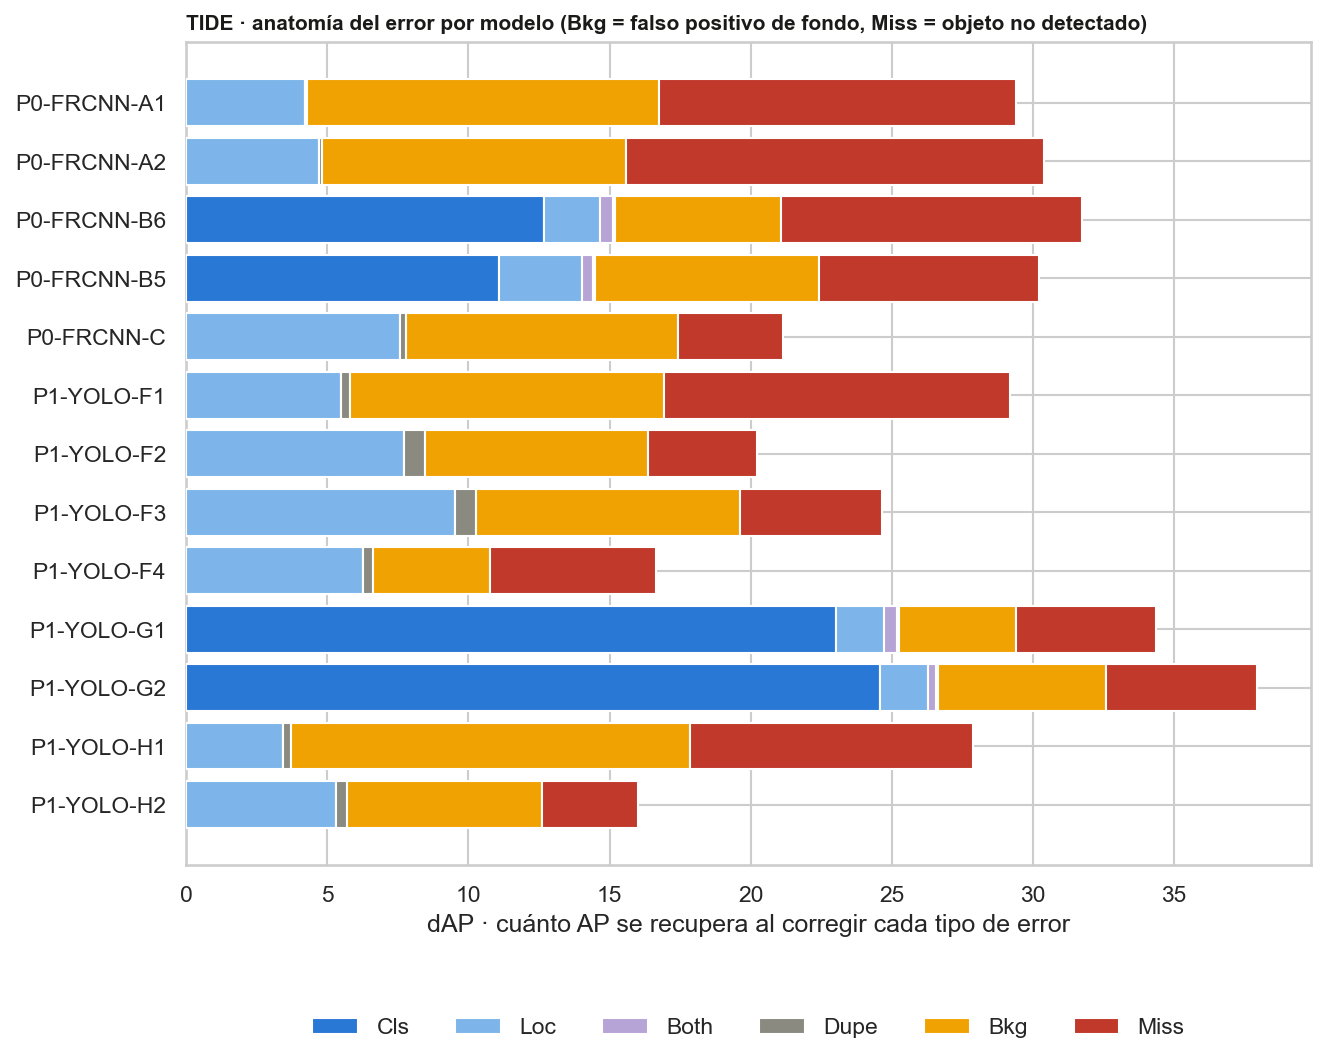

In [7]:
import re, warnings, tempfile


def _pares_tide():
    """(etiqueta, gt_path, preds_path) para cada modelo con predicciones de su propio test."""
    pares = []
    for e in ("A1", "A2", "B6", "B5", "C"):
        m = done(RUNS_P0, e)
        p = RUNS_P0 / e / "predicciones_test.json"
        if m and p.exists():
            gt = GOLD / "coco" / "{}_test.json".format(m["config"]["exp_gold"])
            pares.append(("P0-FRCNN-" + e, gt, p))
    for e in ("F1", "F2", "F3", "F4", "G1", "G2", "H1", "H2"):
        m = done(RUNS_P1, e)
        if not m:
            continue
        g = m["config"].get("gold")
        p = RUNS_P1 / e / "preds_{}_test.json".format(g)
        if p.exists():
            pares.append(("P1-YOLO-" + e, GOLD / "coco" / "{}_test.json".format(g), p))
    return pares


def _gt_tide(gt_path):
    """tidecv exige 'segmentation' e 'iscrowd' en cada anotación y los GT bbox-only
    (RoLID/UAV) no los llevan — el KeyError que abortaba esta sección. Se genera
    una copia temporal parcheada (polígono = rectángulo del bbox); gold no se toca."""
    d = json.loads(Path(gt_path).read_text())
    anns = d.get("annotations", [])
    if all(a.get("segmentation") and "iscrowd" in a for a in anns):
        return str(gt_path)
    for a in anns:
        a.setdefault("iscrowd", 0)
        if not a.get("segmentation"):
            x, y, w, h = a["bbox"]
            a["segmentation"] = [[x, y, x + w, y, x + w, y + h, x, y + h]]
    tmp = Path(tempfile.gettempdir()) / ("tide_" + Path(gt_path).name)
    tmp.write_text(json.dumps(d))
    return str(tmp)


def _parsear_tide(texto):
    """AP50 y los dAP desde la salida de summarize() — estable entre versiones."""
    out = {}
    m = re.search(r"^\s*AP\s+([\d.]+)", texto, re.M)
    if m:
        out["AP50"] = float(m.group(1))
    bloques = re.findall(r"dAP\s+((?:[\d.]+\s+)+)", texto)
    if bloques:
        v = [float(x) for x in bloques[0].split()]
        if len(v) == 6:
            out.update(dict(zip(("Cls", "Loc", "Both", "Dupe", "Bkg", "Miss"), v)))
    if len(bloques) > 1:
        v = [float(x) for x in bloques[1].split()]
        if len(v) == 2:
            out.update(dict(zip(("FalsePos", "FalseNeg"), v)))
    return out


pares = _pares_tide()
titulo("TIDE · {} modelo(s) con predicciones disponibles".format(len(pares)))
resumen_tide, filas_tide, tide_df = {}, [], None
if not pares:
    print("[omitido] sin predicciones de test aún")
else:
    try:
        from tidecv import TIDE, datasets as tide_datasets
        warnings.filterwarnings("ignore")
        for etiqueta, gt_path, preds_path in pares:
            # guardián por modelo: un GT o unas predicciones problemáticas no
            # deben descartar la descomposición de los demás
            try:
                if not json.loads(preds_path.read_text()):
                    print("  {:16s} predicciones vacías — omitido".format(etiqueta))
                    continue
                t = TIDE()
                with contextlib.redirect_stdout(io.StringIO()) as buf:
                    t.evaluate_range(tide_datasets.COCO(_gt_tide(gt_path)),
                                     tide_datasets.COCOResult(str(preds_path)),
                                     mode=TIDE.BOX)
                    t.summarize()
                texto = buf.getvalue()
                resumen_tide[etiqueta] = texto
                nums = _parsear_tide(texto)
                filas_tide.append({"modelo": etiqueta, **nums})
                print("  {:16s} AP50 {:5.1f} · dAP: Cls {:4.1f}  Loc {:4.1f}  Bkg {:4.1f}  "
                      "Miss {:4.1f}  ·  FP {:4.1f}  FN {:4.1f}".format(
                          etiqueta, nums.get("AP50", float("nan")),
                          nums.get("Cls", float("nan")), nums.get("Loc", float("nan")),
                          nums.get("Bkg", float("nan")), nums.get("Miss", float("nan")),
                          nums.get("FalsePos", float("nan")),
                          nums.get("FalseNeg", float("nan"))))
            except Exception as e:
                print("  {:16s} no evaluado ({}: {})".format(
                    etiqueta, type(e).__name__, str(e)[:120]))
        if resumen_tide:
            (TAB_DIR / "tide_resumen.txt").write_text(
                "\n\n".join("### {}\n{}".format(k, v) for k, v in resumen_tide.items()))
    except Exception as e:
        print("[aviso] TIDE no disponible ({}: {}) — la descomposición se omite; "
              "el resto de la evaluación no depende de ella".format(type(e).__name__, e))

if filas_tide:
    tide_df = pd.DataFrame(filas_tide).set_index("modelo")
    tide_df.to_csv(TAB_DIR / "tide_errores.csv")
    print("\nexportada -> {}".format(TAB_DIR / "tide_errores.csv"))

    tipos = [t for t in ("Cls", "Loc", "Both", "Dupe", "Bkg", "Miss")
             if t in tide_df.columns]
    col_err = {"Cls": "#2a78d6", "Loc": "#7db4ea", "Both": "#b7a4d6",
               "Dupe": "#8a8a80", "Bkg": "#f0a202", "Miss": "#c0392b"}
    dfp = tide_df[tipos].fillna(0).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(dfp) + 1.8))
    izq = np.zeros(len(dfp))
    for tp in tipos:
        ax.barh(dfp.index, dfp[tp], left=izq, color=col_err[tp], label=tp, zorder=3)
        izq += dfp[tp].values
    ax.set_xlabel("dAP · cuánto AP se recupera al corregir cada tipo de error")
    ax.set_title("TIDE · anatomía del error por modelo (Bkg = falso positivo de fondo, "
                 "Miss = objeto no detectado)", loc="left", fontsize=10)
    ax.legend(ncol=len(tipos), loc="upper center", bbox_to_anchor=(0.5, -0.16))
    mostrar(fig, "tide_descomposicion")

## Parte 6b · Figuras con rótulos en inglés

El paper y el póster en inglés usan las mismas cinco figuras clave; aquí se
regeneran desde los mismos CSV/JSON con los textos traducidos y se guardan como
`*_en.png` en `figuras_final/`. Las versiones en español (arriba) siguen siendo
las canónicas de las notebooks.

In [ ]:
# ── Figuras EN: mismos datos, mismos estilos, textos traducidos ──────────────

# 1 · Cross-domain matrix
p = RUNS_P1 / "matriz_cross_domain.json"
if p.exists():
    det = json.loads(p.read_text())
    doms = ["taco", "rolid", "uav"]
    M = pd.DataFrame(index=doms, columns=doms, dtype=float)
    Ms = pd.DataFrame(index=doms, columns=doms, dtype=float)
    for k, v in det.items():
        a, b = k.split("->")
        M.loc[a, b] = v["ap50"]; Ms.loc[a, b] = v.get("ap_s", float("nan"))
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
    for ax, Mx, t in ((axes[0], M, "AP50"), (axes[1], Ms, "AP small")):
        vals = Mx.values.astype(float)
        im = ax.imshow(np.nan_to_num(vals, nan=0), cmap="YlOrRd", vmin=0)
        ax.set_xticks(range(3)); ax.set_xticklabels(["test " + c for c in doms])
        ax.set_yticks(range(3)); ax.set_yticklabels(["train " + c for c in doms])
        for i in range(3):
            for j in range(3):
                v = vals[i, j]
                ax.text(j, i, "-" if np.isnan(v) else "{:.3f}".format(v),
                        ha="center", va="center", fontsize=9,
                        color="white" if (not np.isnan(v) and v > np.nanmax(vals) * 0.6)
                        else TINTA_1)
        ax.set_title("Cross-domain matrix · " + t, loc="left"); ax.grid(False)
        fig.colorbar(im, ax=ax, shrink=0.75)
    mostrar(fig, "matriz_cross_domain_final_en")

# 2 · Leakage
p = RUNS_P1 / "oficial_vs_video.json"
if p.exists():
    df = pd.DataFrame(json.loads(p.read_text())).T
    vals = df["AP50"].astype(float)
    etiq = ["F3 · official test\n(58% train-test leak)",
            "F2 · by-video test\n(honest scheme, 0% leak)",
            "F3 · by-video test\n(trained on the test videos)"]
    colores = [TINTA_3, PAL["rolid"], "#c0392b"]
    fig, ax = plt.subplots(figsize=(7.2, 3.7))
    ax.bar(range(len(vals)), vals, color=colores[:len(vals)], width=0.62, zorder=3)
    for x, v in enumerate(vals):
        ax.text(x, v + 0.012, "{:.3f}".format(v), ha="center", fontsize=10,
                fontweight="bold", color=TINTA_1)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(etiq[:len(vals)], fontsize=8)
    ax.set_ylabel("AP50 (test)")
    ax.set_ylim(0, float(vals.max()) * 1.2)
    if len(vals) >= 3:
        ax.annotate("+{:.3f} inflation\nfrom video memory".format(
                        float(vals.iloc[2]) - float(vals.iloc[1])),
                    xy=(2, float(vals.iloc[2])),
                    xytext=(1.28, float(vals.iloc[2]) * 1.03),
                    fontsize=8, color="#c0392b",
                    arrowprops=dict(arrowstyle="->", color="#c0392b"))
    ax.set_title("H4 · the model that saw the test videos looks better than it is",
                 loc="left")
    mostrar(fig, "fuga_oficial_vs_video_en")

# 3 · Resolution ablation
p = RUNS_P1 / "ablacion_resolucion.json"
if p.exists():
    df = pd.DataFrame(json.loads(p.read_text())).T
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.9), sharey=True)
    for ax, (c640, c1024, t) in zip(axes, (("AP50@640", "AP50@1024", "AP50"),
                                           ("AP_s@640", "AP_s@1024", "AP small"))):
        for y, (ds, fila) in enumerate(df.iterrows()):
            col = PAL.get(ds, TINTA_2)
            a, b = float(fila[c640]), float(fila[c1024])
            ax.plot([a, b], [y, y], color=col, lw=2, zorder=3)
            ax.scatter([a], [y], s=46, color=SUPERFICIE, edgecolor=col, lw=2, zorder=4)
            ax.scatter([b], [y], s=56, color=col, zorder=4)
            ax.text(b + 0.014, y, "{:+.3f}".format(b - a), va="center", fontsize=8,
                    color=col, fontweight="bold")
        ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index)
        ax.set_title("{} · 640 (outline) -> 1024 (filled)".format(t), loc="left",
                     fontsize=9)
        ax.set_xlim(left=0)
        ax.margins(x=0.14)
    fig.suptitle("Resolution ablation · 1024 px pays most where objects are smallest",
                 x=0.01, ha="left", fontsize=11, fontweight="bold", color=TINTA_1)
    mostrar(fig, "ablacion_resolucion_en")

# 4 · Family comparison
p = TAB_DIR / "comparativa_familias.csv"
if p.exists():
    comp = pd.read_csv(p)
    piv = comp.pivot_table(index="datos", columns="familia", values="test_AP50")
    datasets_disp = piv.index.tolist()
    x = np.arange(len(datasets_disp)); w = 0.35
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for i, fam in enumerate([f for f in ("FRCNN", "YOLO") if f in piv.columns]):
        ax.bar(x + (i - 0.5) * w, piv[fam], w, color=COL_FAM[fam],
               label="{} ({} M params)".format(fam, PARAMS_M[fam]), zorder=3)
        for xi, v in zip(x + (i - 0.5) * w, piv[fam]):
            if pd.notna(v):
                ax.text(xi, v + 0.005, "{:.3f}".format(v), ha="center", fontsize=8,
                        color=TINTA_1)
    ax.set_xticks(x); ax.set_xticklabels(datasets_disp, rotation=10)
    ax.set_ylabel("AP50 (test)")
    ax.set_title("Faster R-CNN vs YOLOv11n · same data, same splits", loc="left")
    ax.legend()
    mostrar(fig, "comparativa_familias_en")

# 5 · TIDE
p = TAB_DIR / "tide_errores.csv"
if p.exists():
    tdf = pd.read_csv(p).set_index("modelo")
    tipos = [t for t in ("Cls", "Loc", "Both", "Dupe", "Bkg", "Miss")
             if t in tdf.columns]
    col_err = {"Cls": "#2a78d6", "Loc": "#7db4ea", "Both": "#b7a4d6",
               "Dupe": "#8a8a80", "Bkg": "#f0a202", "Miss": "#c0392b"}
    dfp = tdf[tipos].fillna(0).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(dfp) + 1.8))
    izq = np.zeros(len(dfp))
    for tp in tipos:
        ax.barh(dfp.index, dfp[tp], left=izq, color=col_err[tp], label=tp, zorder=3)
        izq += dfp[tp].values
    ax.set_xlabel("dAP · AP recovered by fixing each error type")
    ax.set_title("TIDE · error anatomy per model (Bkg = background false positive, "
                 "Miss = undetected object)", loc="left", fontsize=10)
    ax.legend(ncol=len(tipos), loc="upper center", bbox_to_anchor=(0.5, -0.16))
    mostrar(fig, "tide_descomposicion_en")

print("figuras EN guardadas en figuras_final/*_en.png")

## Parte 7 · Consolidación final

In [8]:
titulo("RESULTADOS FINALES")
final = {
    "generado": datetime.datetime.now().isoformat(timespec="seconds"),
    "experimentos_done": int((inv["estado"] == "DONE").sum()),
    "de": len(inv),
}
if maestra is not None:
    final["maestra"] = json.loads(maestra.reset_index().to_json(orient="records"))
for nombre in ("matriz_cross_domain", "oficial_vs_video", "ablacion_resolucion",
               "variantes_ab"):
    p = RUNS_P1 / (nombre + ".json")
    if p.exists():
        final[nombre] = json.loads(p.read_text())
if resumen_tide:
    final["tide_modelos"] = sorted(resumen_tide)
if isinstance(tide_df, pd.DataFrame) and len(tide_df):
    final["tide_errores"] = json.loads(tide_df.reset_index().to_json(orient="records"))

(CODE_DIR / "reports" / "resultados_finales.json").write_text(
    json.dumps(final, indent=2, ensure_ascii=False, default=float))
print("reports/resultados_finales.json escrito · {} experimentos consolidados".format(
    final["experimentos_done"]))
print("tablas CSV en reports/tablas/ · figuras en reports/figuras_final/")
print("""
Con los 19 experimentos DONE, este archivo + los CSV alimentan directamente:
  - las tablas 1-4 del paper (maestra, familias, matriz, análisis)
  - las figuras principales (maestra, matriz, comparativa, fuga, ablación, A/B, TIDE)
  - el capítulo 5 del README""")


════════════════════════════════════════════════════════════════════════════════════════════════
RESULTADOS FINALES
════════════════════════════════════════════════════════════════════════════════════════════════
reports/resultados_finales.json escrito · 19 experimentos consolidados
tablas CSV en reports/tablas/ · figuras en reports/figuras_final/

Con los 19 experimentos DONE, este archivo + los CSV alimentan directamente:
  - las tablas 1-4 del paper (maestra, familias, matriz, análisis)
  - las figuras principales (maestra, matriz, comparativa, fuga, ablación, A/B, TIDE)
  - el capítulo 5 del README


## Notas

- **Reejecutar en cualquier momento**: cada sección lee lo que exista; conforme la Mac
  (P1) y Colab (P0) cierren experimentos, las tablas y figuras se completan solas.
- Los CSV de `reports/tablas/` son la fuente de las tablas del paper no se transcriben
  números a mano.
- Si `tidecv` fallara en algún entorno, la sección TIDE se omite con aviso y nada más
  se ve afectado.